# UTS 31250 Introduction to Data Analytics

## Assessment Task 2: Data Exploration and Preparation

**Student Number:** 25740123

## P0. Data Audit and Setup

This section checks the structure and quality of the raw dataset before the assessed analysis begins. It verifies the dataset dimensions, missing values and several key consistency checks without modifying the original data.

P0 is a preparation and quality assurance step. It is not one of the assessed A or B tasks.

Two rules apply throughout this section. First, the raw file `25740123.csv` is never edited. Second, blank cells in the raw file are treated as missing values and are never read as zero. Nothing is imputed and no rows are removed here.

### P0.1 Import the libraries

Only pandas and numpy are needed for the audit. pandas is used to read the comma separated file and to summarise it, and numpy supports the numeric work. The library versions are printed so that the run can be reproduced later.

In [1]:
import hashlib

import numpy as np
import pandas as pd

pd.set_option("display.max_columns", 50)
pd.set_option("display.width", 160)

print("pandas version:", pd.__version__)
print("numpy version:", np.__version__)

pandas version: 3.0.3
numpy version: 2.4.6


### P0.2 Load the raw data

The raw file is read into a DataFrame named `df_raw`. This object is treated as read only for the whole notebook. Where a check needs a transformed value, a separate copy or Series is created instead of changing `df_raw`.

By default pandas reads an empty field as `NaN`, which is the correct behaviour here because a blank cell means the value was not recorded.

In [2]:
RAW_CSV = "25740123.csv"

df_raw = pd.read_csv(RAW_CSV)

print("Dataset shape:", df_raw.shape)
print("Number of rows:", df_raw.shape[0])
print("Number of columns:", df_raw.shape[1])

Dataset shape: (4349, 25)
Number of rows: 4349
Number of columns: 25


The full ordered list of attribute names is printed next, because later sections refer to these attributes by name and the order matters when the audit table is read.

In [3]:
print("Ordered column names:")
for position, column_name in enumerate(df_raw.columns, start=1):
    print(position, column_name)

Ordered column names:
1 O_CITY
2 O_STATE
3 D_CITY
4 D_STATE
5 SCHEDULED_DEPARTURE
6 DEPARTURE_TIME
7 DEPARTURE_DELAY
8 TAXI_OUT
9 WHEELS_OFF
10 SCHEDULED_TIME
11 ELAPSED_TIME
12 AIR_TIME
13 DISTANCE
14 WHEELS_ON
15 TAXI_IN
16 SCHEDULED_ARRIVAL
17 ARRIVAL_TIME
18 ARRIVAL_DELAY
19 DIVERTED
20 CANCELLED
21 AIR_SYSTEM_DELAY
22 SECURITY_DELAY
23 WEATHER_DELAY
24 DATE
25 AIRLINE_NAME


A short preview of the first rows confirms that the file was read with the correct header row and that the columns are aligned as expected.

In [4]:
df_raw.head()

,O_CITY,O_STATE,D_CITY,D_STATE,SCHEDULED_DEPARTURE,DEPARTURE_TIME,DEPARTURE_DELAY,TAXI_OUT,WHEELS_OFF,SCHEDULED_TIME,ELAPSED_TIME,AIR_TIME,DISTANCE,WHEELS_ON,TAXI_IN,SCHEDULED_ARRIVAL,ARRIVAL_TIME,ARRIVAL_DELAY,DIVERTED,CANCELLED,AIR_SYSTEM_DELAY,SECURITY_DELAY,WEATHER_DELAY,DATE,AIRLINE_NAME
0,Chicago,IL,Omaha,NE,1655,1706.0,11.0,8.0,1714.0,80,72.0,60.0,423,1814.0,4.0,1815,1818.0,3.0,0,0,NaN,NaN,NaN,2015-9-6,Southwest Airlines Co.
1,Ontario,CA,Salt Lake City,UT,1630,1625.0,-5.0,14.0,1639.0,108,100.0,81.0,558,1900.0,5.0,1918,1905.0,-13.0,0,0,NaN,NaN,NaN,2015-2-23,Skywest Airlines Inc.
2,Charlotte Amalie,VI,Atlanta,GA,1510,1526.0,16.0,11.0,1537.0,250,247.0,230.0,1599,1827.0,6.0,1820,1833.0,13.0,0,0,NaN,NaN,NaN,2015-1-16,Delta Air Lines Inc.
3,Salt Lake City,UT,Oakland,CA,1505,1505.0,0.0,14.0,1519.0,119,102.0,82.0,588,1541.0,6.0,1604,1547.0,-17.0,0,0,NaN,NaN,NaN,2015-12-1,Delta Air Lines Inc.
4,Fargo,ND,Denver,CO,1712,1805.0,53.0,11.0,1816.0,123,125.0,95.0,627,1851.0,19.0,1815,1910.0,55.0,0,0,2.0,0.0,0.0,2015-2-4,Skywest Airlines Inc.


### P0.3 Attribute audit table

This table gives one row per attribute and records the pandas data type, how many values are present, how many are missing, the missing percentage and how many distinct values occur. The missing percentage is calculated from the actual number of rows in the file rather than from an assumed row count.

The table is a new DataFrame, so building it does not change `df_raw`.

In [5]:
total_rows = len(df_raw)
audit_rows = []

for column_name in df_raw.columns:
    column = df_raw[column_name]
    missing_count = int(column.isna().sum())
    audit_rows.append({
        "Attribute": column_name,
        "Pandas dtype": str(column.dtype),
        "Non-missing count": int(column.notna().sum()),
        "Missing count": missing_count,
        "Missing percentage": round(100 * missing_count / total_rows, 2),
        "Unique values": int(column.nunique(dropna=True)),
    })

audit_table = pd.DataFrame(audit_rows)
audit_table

,Attribute,Pandas dtype,Non-missing count,Missing count,Missing percentage,Unique values
0,O_CITY,str,4349,0,0.00,213
1,O_STATE,str,4349,0,0.00,52
2,D_CITY,str,4349,0,0.00,214
3,D_STATE,str,4349,0,0.00,51
4,SCHEDULED_DEPARTURE,int64,4349,0,0.00,806
5,DEPARTURE_TIME,float64,4288,61,1.40,1084
6,DEPARTURE_DELAY,float64,4288,61,1.40,204
7,TAXI_OUT,float64,4284,65,1.49,73
8,WHEELS_OFF,float64,4284,65,1.49,1082
9,SCHEDULED_TIME,int64,4349,0,0.00,350


The audit table is saved so that it can be referenced later without rerunning the whole notebook.

In [6]:
audit_table.to_csv("outputs/P0_data_audit.csv", index=False)
print("Saved outputs/P0_data_audit.csv with", len(audit_table), "attribute rows.")

Saved outputs/P0_data_audit.csv with 25 attribute rows.


### P0.4 Duplicate rows

An exact duplicate row would mean the same flight record appears twice. This check counts rows that are identical across all 25 attributes.

In [7]:
duplicate_row_count = int(df_raw.duplicated().sum())
print("Exact duplicate rows:", duplicate_row_count)

Exact duplicate rows: 0


### P0.5 Missing values and unique values for every attribute

The audit table above already contains this information, but printing the two series separately makes the pattern of missing data easier to read.

In [8]:
print("Missing values per attribute:")
print(df_raw.isna().sum())

Missing values per attribute:
O_CITY                    0
O_STATE                   0
D_CITY                    0
D_STATE                   0
SCHEDULED_DEPARTURE       0
DEPARTURE_TIME           61
DEPARTURE_DELAY          61
TAXI_OUT                 65
WHEELS_OFF               65
SCHEDULED_TIME            0
ELAPSED_TIME             84
AIR_TIME                 84
DISTANCE                  0
WHEELS_ON                67
TAXI_IN                  67
SCHEDULED_ARRIVAL         0
ARRIVAL_TIME             67
ARRIVAL_DELAY            84
DIVERTED                  0
CANCELLED                 0
AIR_SYSTEM_DELAY       3522
SECURITY_DELAY         3522
WEATHER_DELAY          3522
DATE                      0
AIRLINE_NAME              0
dtype: int64


In [9]:
print("Unique values per attribute:")
print(df_raw.nunique(dropna=True))

Unique values per attribute:
O_CITY                  213
O_STATE                  52
D_CITY                  214
D_STATE                  51
SCHEDULED_DEPARTURE     806
DEPARTURE_TIME         1084
DEPARTURE_DELAY         204
TAXI_OUT                 73
WHEELS_OFF             1082
SCHEDULED_TIME          350
ELAPSED_TIME            353
AIR_TIME                334
DISTANCE                930
WHEELS_ON              1126
TAXI_IN                  50
SCHEDULED_ARRIVAL      1024
ARRIVAL_TIME           1133
ARRIVAL_DELAY           236
DIVERTED                  2
CANCELLED                 2
AIR_SYSTEM_DELAY         81
SECURITY_DELAY            5
WEATHER_DELAY            44
DATE                    334
AIRLINE_NAME              6
dtype: int64


### P0.6 Cancelled and diverted flights

`CANCELLED` and `DIVERTED` are indicator attributes, so they should only contain the values 0 and 1. The number of flights flagged in each attribute is counted.

In [10]:
print("CANCELLED unique values:", sorted(df_raw["CANCELLED"].unique()))
print("DIVERTED unique values:", sorted(df_raw["DIVERTED"].unique()))

cancelled_count = int((df_raw["CANCELLED"] == 1).sum())
diverted_count = int((df_raw["DIVERTED"] == 1).sum())

print("Rows where CANCELLED == 1:", cancelled_count)
print("Rows where DIVERTED == 1:", diverted_count)

CANCELLED unique values: [np.int64(0), np.int64(1)]
DIVERTED unique values: [np.int64(0), np.int64(1)]
Rows where CANCELLED == 1: 66
Rows where DIVERTED == 1: 18


### P0.7 Airlines

The number of distinct airline names is counted and the names are listed, so that the categorical attribute can be described accurately in the later sections.

In [11]:
airline_names = sorted(df_raw["AIRLINE_NAME"].dropna().unique())
number_of_airlines = int(df_raw["AIRLINE_NAME"].nunique(dropna=True))

print("Number of airlines:", number_of_airlines)
for airline in airline_names:
    print("-", airline)

Number of airlines: 6
- American Airlines Inc.
- Atlantic Southeast Airlines
- Delta Air Lines Inc.
- Skywest Airlines Inc.
- Southwest Airlines Co.
- United Air Lines Inc.


### P0.8 Date range

`DATE` is stored as text in the raw file, and the values are not zero padded, for example `2015-9-6`. To check the date range the text is parsed into a temporary Series called `date_parsed` using the explicit format `%Y-%m-%d`. Giving the format explicitly avoids any guessing about whether the day or the month comes first.

`df_raw["DATE"]` itself is left as text, and the last two lines confirm that.

In [12]:
print("Original DATE dtype:", df_raw["DATE"].dtype)

date_parsed = pd.to_datetime(df_raw["DATE"], format="%Y-%m-%d")

print("Parsed minimum date:", date_parsed.min().date())
print("Parsed maximum date:", date_parsed.max().date())
print("Dates that failed to parse:", int(date_parsed.isna().sum()))

print("DATE dtype in df_raw after parsing:", df_raw["DATE"].dtype)
print("First DATE value in df_raw:", repr(df_raw["DATE"].iloc[0]))

Original DATE dtype: str
Parsed minimum date: 2015-01-01
Parsed maximum date: 2015-12-31
Dates that failed to parse: 0
DATE dtype in df_raw after parsing: str
First DATE value in df_raw: '2015-9-6'


### P0.9 ARRIVAL_DELAY audit

`ARRIVAL_DELAY` is the main outcome attribute for this dataset, measured in minutes, where a negative value means the flight arrived early. Missing values are counted as missing and are never treated as a delay of zero. All statistics below are therefore calculated on the non-missing values only, which is what pandas does by default.

In [13]:
arrival_delay = df_raw["ARRIVAL_DELAY"]

arrival_delay_non_missing = int(arrival_delay.notna().sum())
arrival_delay_min = float(arrival_delay.min())
arrival_delay_max = float(arrival_delay.max())
arrival_delay_negative = int((arrival_delay < 0).sum())

print("Non-missing ARRIVAL_DELAY values:", arrival_delay_non_missing)
print("Missing ARRIVAL_DELAY values:", int(arrival_delay.isna().sum()))
print("Minimum ARRIVAL_DELAY:", arrival_delay_min, "minutes")
print("Maximum ARRIVAL_DELAY:", arrival_delay_max, "minutes")
print("Non-missing values below zero (early arrivals):", arrival_delay_negative)

Non-missing ARRIVAL_DELAY values: 4265
Missing ARRIVAL_DELAY values: 84
Minimum ARRIVAL_DELAY: -61.0 minutes
Maximum ARRIVAL_DELAY: 865.0 minutes
Non-missing values below zero (early arrivals): 2633


### P0.10 Why the values are missing

The missing values in this dataset are not random. A cancelled flight never departs and a diverted flight never lands at the scheduled destination, so no arrival time can be recorded. This section tests whether the rows with a missing `ARRIVAL_DELAY` are exactly the rows that were cancelled or diverted.

Counting alone is not enough, because two different sets of rows can still have the same size. The comparison below uses `Series.equals`, which compares the True and False pattern row by row, and it is confirmed with a comparison of the row index sets.

In [14]:
is_cancelled = df_raw["CANCELLED"] == 1
is_diverted = df_raw["DIVERTED"] == 1
cancelled_or_diverted = is_cancelled | is_diverted

arrival_delay_missing = df_raw["ARRIVAL_DELAY"].isna()
elapsed_time_missing = df_raw["ELAPSED_TIME"].isna()

print("Cancelled flights:", int(is_cancelled.sum()))
print("Diverted flights:", int(is_diverted.sum()))
print("Cancelled or diverted flights:", int(cancelled_or_diverted.sum()))
print("Rows with missing ARRIVAL_DELAY:", int(arrival_delay_missing.sum()))
print("Rows with missing ELAPSED_TIME:", int(elapsed_time_missing.sum()))

Cancelled flights: 66
Diverted flights: 18
Cancelled or diverted flights: 84
Rows with missing ARRIVAL_DELAY: 84
Rows with missing ELAPSED_TIME: 84


In [15]:
arrival_rows_match = bool(arrival_delay_missing.equals(cancelled_or_diverted))
elapsed_rows_match = bool(elapsed_time_missing.equals(cancelled_or_diverted))

flagged_index = set(df_raw.index[cancelled_or_diverted])
arrival_index_match = set(df_raw.index[arrival_delay_missing]) == flagged_index
elapsed_index_match = set(df_raw.index[elapsed_time_missing]) == flagged_index

print("Missing ARRIVAL_DELAY rows equal cancelled or diverted rows:", arrival_rows_match)
print("Missing ELAPSED_TIME rows equal cancelled or diverted rows:", elapsed_rows_match)
print("Same result using row index sets, ARRIVAL_DELAY:", arrival_index_match)
print("Same result using row index sets, ELAPSED_TIME:", elapsed_index_match)

Missing ARRIVAL_DELAY rows equal cancelled or diverted rows: True
Missing ELAPSED_TIME rows equal cancelled or diverted rows: True
Same result using row index sets, ARRIVAL_DELAY: True
Same result using row index sets, ELAPSED_TIME: True


### P0.11 The three delay-cause attributes

`AIR_SYSTEM_DELAY`, `SECURITY_DELAY` and `WEATHER_DELAY` break a late arrival down into its causes. These attributes have a very high number of missing values, so it is important to understand why before any later section uses them.

Two things are tested. First, whether the three attributes are missing on exactly the same rows. Second, whether the rows that do have values are exactly the rows where `ARRIVAL_DELAY` is 15 minutes or more, which is the usual reporting threshold for a delayed flight.

In [16]:
air_system_missing = df_raw["AIR_SYSTEM_DELAY"].isna()
security_missing = df_raw["SECURITY_DELAY"].isna()
weather_missing = df_raw["WEATHER_DELAY"].isna()

same_as_security = bool(air_system_missing.equals(security_missing))
same_as_weather = bool(air_system_missing.equals(weather_missing))

print("AIR_SYSTEM_DELAY missing on the same rows as SECURITY_DELAY:", same_as_security)
print("AIR_SYSTEM_DELAY missing on the same rows as WEATHER_DELAY:", same_as_weather)
print("Rows where the delay causes are recorded:", int((~air_system_missing).sum()))

AIR_SYSTEM_DELAY missing on the same rows as SECURITY_DELAY: True
AIR_SYSTEM_DELAY missing on the same rows as WEATHER_DELAY: True
Rows where the delay causes are recorded: 827


In [17]:
delay_15_or_more = df_raw["ARRIVAL_DELAY"] >= 15
delay_causes_recorded = ~air_system_missing

delay_cause_rows_match = bool(delay_causes_recorded.equals(delay_15_or_more))

print("Rows where ARRIVAL_DELAY is 15 minutes or more:", int(delay_15_or_more.sum()))
print("Recorded delay-cause rows equal those rows:", delay_cause_rows_match)

Rows where ARRIVAL_DELAY is 15 minutes or more: 827
Recorded delay-cause rows equal those rows: True


### P0.12 Validation table

The assignment brief describes what this dataset should look like. Every expected fact is recomputed from the raw file and compared with the expected value. The expected values are only used as a target for comparison, and no value is ever written back into the data to force a match.

In [18]:
expected_missing_counts = {
    "DEPARTURE_TIME": 61,
    "DEPARTURE_DELAY": 61,
    "TAXI_OUT": 65,
    "WHEELS_OFF": 65,
    "WHEELS_ON": 67,
    "TAXI_IN": 67,
    "ARRIVAL_TIME": 67,
    "ELAPSED_TIME": 84,
    "AIR_TIME": 84,
    "ARRIVAL_DELAY": 84,
    "AIR_SYSTEM_DELAY": 3522,
    "SECURITY_DELAY": 3522,
    "WEATHER_DELAY": 3522,
}

validation_rows = []

def record_check(check_name, expected_value, observed_value):
    validation_rows.append({
        "Check": check_name,
        "Expected": str(expected_value),
        "Observed": str(observed_value),
        "Match": str(expected_value) == str(observed_value),
    })

In [19]:
record_check("Dataset rows", 4349, df_raw.shape[0])
record_check("Dataset columns", 25, df_raw.shape[1])
record_check("Date minimum", "2015-01-01", date_parsed.min().date())
record_check("Date maximum", "2015-12-31", date_parsed.max().date())
record_check("Number of airlines", 6, number_of_airlines)

for column_name, expected_count in expected_missing_counts.items():
    record_check("Missing values in " + column_name,
                 expected_count,
                 int(df_raw[column_name].isna().sum()))

other_columns = [c for c in df_raw.columns if c not in expected_missing_counts]
record_check("Attributes expected to have no missing values",
             0,
             int(df_raw[other_columns].isna().sum().sum()))

In [20]:
record_check("Cancelled flights", 66, cancelled_count)
record_check("Diverted flights", 18, diverted_count)
record_check("Cancelled or diverted rows", 84, int(cancelled_or_diverted.sum()))
record_check("Missing ARRIVAL_DELAY count", 84, int(arrival_delay_missing.sum()))
record_check("ARRIVAL_DELAY non-missing count", 4265, arrival_delay_non_missing)
record_check("ARRIVAL_DELAY minimum", -61.0, arrival_delay_min)
record_check("ARRIVAL_DELAY maximum", 865.0, arrival_delay_max)
record_check("Negative ARRIVAL_DELAY count", 2633, arrival_delay_negative)
record_check("Missing ARRIVAL_DELAY row set equals cancelled or diverted", True, arrival_rows_match)
record_check("Missing ELAPSED_TIME row set equals cancelled or diverted", True, elapsed_rows_match)
record_check("Delay causes missing on identical rows", True, same_as_security and same_as_weather)
record_check("Delay-cause rows equal ARRIVAL_DELAY of 15 or more", True, delay_cause_rows_match)
record_check("Rows with ARRIVAL_DELAY of 15 or more", 827, int(delay_15_or_more.sum()))
record_check("Exact duplicate rows", 0, duplicate_row_count)

validation_table = pd.DataFrame(validation_rows)
validation_table

,Check,Expected,Observed,Match
0,Dataset rows,4349,4349,True
1,Dataset columns,25,25,True
2,Date minimum,2015-01-01,2015-01-01,True
3,Date maximum,2015-12-31,2015-12-31,True
4,Number of airlines,6,6,True
5,Missing values in DEPARTURE_TIME,61,61,True
6,Missing values in DEPARTURE_DELAY,61,61,True
7,Missing values in TAXI_OUT,65,65,True
8,Missing values in WHEELS_OFF,65,65,True
9,Missing values in WHEELS_ON,67,67,True


The last step of the validation is a single summary line. If any check had failed, the failing rows would be printed here so that the problem could be reported before any further work was done.

In [21]:
failed_checks = validation_table[validation_table["Match"] == False]

print("Total checks:", len(validation_table))
print("Checks passed:", int((validation_table["Match"] == True).sum()))
print("Checks failed:", len(failed_checks))

if len(failed_checks) == 0:
    print("All expected dataset facts were confirmed from the raw file.")
else:
    print("The following checks did not match the expected values:")
    print(failed_checks)

Total checks: 33
Checks passed: 33
Checks failed: 0
All expected dataset facts were confirmed from the raw file.


### P0.13 Raw file integrity

The final check confirms that the raw file was not altered by this notebook. The SHA-256 hash of `25740123.csv` is recalculated and compared with the hash recorded when the audit was first written. The file size and the row count are also reported. A matching hash means the file is byte for byte identical, so no value was written back, no row was removed and no blank cell was replaced.

In [22]:
RECORDED_CSV_HASH = "676681651e11de53308116df0fc5b2ef72c5b967ec779d0159f747edd10499de"

with open(RAW_CSV, "rb") as raw_file:
    current_csv_hash = hashlib.sha256(raw_file.read()).hexdigest()

print("Recorded SHA-256:", RECORDED_CSV_HASH)
print("Current SHA-256: ", current_csv_hash)
print("Raw file unchanged:", current_csv_hash == RECORDED_CSV_HASH)
print("Rows still loaded from the raw file:", len(df_raw))

Recorded SHA-256: 676681651e11de53308116df0fc5b2ef72c5b967ec779d0159f747edd10499de
Current SHA-256:  676681651e11de53308116df0fc5b2ef72c5b967ec779d0159f747edd10499de
Raw file unchanged: True
Rows still loaded from the raw file: 4349


### P0.14 Audit conclusion

The audit confirmed the structure the assignment brief describes. The file holds 4,349 flight records and 25 attributes, covering every date from 1 January 2015 to 31 December 2015 for six airlines, with no exact duplicate rows.

The missing values fall into two clear groups. The first group is the small number of operational attributes, from `DEPARTURE_TIME` through to `ARRIVAL_DELAY`, where between 61 and 84 values are absent. The 84 rows with no `ARRIVAL_DELAY` or `ELAPSED_TIME` are exactly the 66 cancelled and 18 diverted flights, so these values are missing because the flight did not complete rather than because of a recording error. The second group is the three delay-cause attributes, each missing 3,522 values on identical rows. Their 827 recorded rows are exactly the flights that arrived 15 minutes late or later, so a blank there means the flight was not reportably late, which is very different from a zero.

That distinction matters for the assessed sections. Reading any of these blanks as zero would understate delays and distort the summary statistics, so the raw missing values are carried forward unchanged and how to handle them will be decided as part of the later tasks.

No data was modified in this section. No values were imputed, no rows were removed and no charts were produced, because those belong to the assessed tasks that follow.

## A1. Attribute Types

This section classifies all 25 attributes in the dataset using the four measurement scales: nominal, ordinal, interval and ratio.

The classification is based on what each attribute actually measures, not on how pandas happens to store it. A column of whole numbers is not automatically a quantity, and a column of text is not automatically a category. For each attribute the following properties are considered in turn: whether values are distinct, whether they can be placed in a meaningful order, whether the differences between values are meaningful and equally spaced, and whether the attribute has a true zero that makes ratio statements such as "twice as much" meaningful.

The table below is built in three groups so that each group of related attributes stays readable, and it is then presented in the original dataset order.

### A1.1 Nominal attributes

These attributes record labels. Their values can be compared for equality only, because no value ranks above another and the gap between two labels cannot be measured.

In [23]:
a1_rows = []

a1_rows.append(["O_CITY", "Nominal",
    "The origin city is a distinct place label, so only equality comparisons apply and no order or numerical distance exists."])
a1_rows.append(["O_STATE", "Nominal",
    "State names distinguish one origin region from another but carry no measurement order, so only equality and inequality are meaningful."])
a1_rows.append(["D_CITY", "Nominal",
    "The destination city is a distinct place label with no inherent ranking, and differences between city names cannot be measured."])
a1_rows.append(["D_STATE", "Nominal",
    "Destination states are distinct regional categories, and no state sits at a measurable interval above or below another."])
a1_rows.append(["DIVERTED", "Nominal",
    "The codes 0 and 1 label two flight outcomes rather than measuring an amount, so only distinctness is meaningful."])
a1_rows.append(["CANCELLED", "Nominal",
    "The value 1 marks a cancelled flight and 0 a flight that operated, so the digits act purely as category labels."])
a1_rows.append(["AIRLINE_NAME", "Nominal",
    "Each airline name identifies a distinct carrier, and airlines cannot be placed in a measurement order or spaced by intervals."])

print("Nominal attributes added:", len(a1_rows))

Nominal attributes added: 7


### A1.2 Interval attributes

These attributes are measured against a reference point that is set by convention rather than by nature. Their order and their differences are meaningful, but because zero does not represent an absence of the quantity, a statement such as "twice as much" has no sensible interpretation.

In [24]:
a1_rows.append(["SCHEDULED_DEPARTURE", "Interval",
    "This is a clock point, so times can be ordered and gaps between them compared, but midnight is a conventional origin."])
a1_rows.append(["DEPARTURE_TIME", "Interval",
    "The actual departure clock time can be ordered and differences between two times are meaningful, yet the zero point is conventional."])
a1_rows.append(["DEPARTURE_DELAY", "Interval",
    "Delay is a signed offset in minutes from the schedule, where zero means on time rather than an absence of quantity."])
a1_rows.append(["WHEELS_OFF", "Interval",
    "The moment the wheels leave the ground is a point on the clock, so differences are meaningful but ratios are not."])
a1_rows.append(["WHEELS_ON", "Interval",
    "Touchdown is recorded as a clock point, so intervals between events are meaningful while a doubled clock value has no interpretation."])
a1_rows.append(["SCHEDULED_ARRIVAL", "Interval",
    "The planned arrival clock time is ordered with meaningful gaps between times, but it has no true zero for arrival."])
a1_rows.append(["ARRIVAL_TIME", "Interval",
    "The actual arrival clock time supports ordering and meaningful differences, although the origin of the clock is set by convention."])
a1_rows.append(["ARRIVAL_DELAY", "Interval",
    "Arrival delay is a signed deviation from schedule and includes negative values for early arrivals, so ratio comparisons are not meaningful."])
a1_rows.append(["DATE", "Interval",
    "Calendar dates can be ordered and differences in days are meaningful, but the start of the calendar is a convention."])

print("Attributes added so far:", len(a1_rows))

Attributes added so far: 16


### A1.3 Ratio attributes

These attributes measure an amount of something. Zero means that none of the quantity is present, so differences and ratios are both meaningful.

In [25]:
a1_rows.append(["TAXI_OUT", "Ratio",
    "This is a duration in minutes where zero means no time elapsed taxiing, so differences and ratios are both meaningful."])
a1_rows.append(["SCHEDULED_TIME", "Ratio",
    "The planned trip length is a duration with a true zero, so one flight can be meaningfully twice as long as another."])
a1_rows.append(["ELAPSED_TIME", "Ratio",
    "Total elapsed time measures an amount of time with a genuine zero, which allows meaningful differences and ratio comparisons."])
a1_rows.append(["AIR_TIME", "Ratio",
    "Time airborne is a measured duration where zero represents no time in the air, so ratio statements are meaningful."])
a1_rows.append(["DISTANCE", "Ratio",
    "Distance has a true zero at no separation and equal units, so one route can be meaningfully twice as far as another."])
a1_rows.append(["TAXI_IN", "Ratio",
    "The taxi-in duration counts minutes from a genuine zero, so both differences and ratio comparisons between flights are meaningful."])
a1_rows.append(["AIR_SYSTEM_DELAY", "Ratio",
    "When recorded, this is an amount of delay caused by the air system, and zero minutes is a meaningful absence of it."])
a1_rows.append(["SECURITY_DELAY", "Ratio",
    "When recorded, this measures minutes of delay attributed to security, with zero representing no such delay contribution."])
a1_rows.append(["WEATHER_DELAY", "Ratio",
    "When recorded, this measures minutes of delay attributed to weather, and zero marks a true absence of weather delay."])

print("Total attributes classified:", len(a1_rows))

Total attributes classified: 25


### A1.4 The complete A1 classification table

The three groups are combined into one table and then sorted back into the original dataset column order, so the table can be read alongside the P0 audit. The order is taken from `df_raw.columns` rather than from typing the 25 names again, so the table order always follows the data itself.

In [26]:
a1_table = pd.DataFrame(a1_rows, columns=["Attribute", "Attribute Type", "Justification"])

# Sort the rows into the original dataset column order, taken from the data itself.
attribute_order = list(df_raw.columns)
a1_table["Dataset position"] = a1_table["Attribute"].map(attribute_order.index)
a1_table = a1_table.sort_values("Dataset position").reset_index(drop=True)
a1_table = a1_table.drop(columns="Dataset position")

print("A1 table shape:", a1_table.shape)
a1_table

A1 table shape: (25, 3)


,Attribute,Attribute Type,Justification
0,O_CITY,Nominal,"The origin city is a distinct place label, so ..."
1,O_STATE,Nominal,State names distinguish one origin region from...
2,D_CITY,Nominal,The destination city is a distinct place label...
3,D_STATE,Nominal,Destination states are distinct regional categ...
4,SCHEDULED_DEPARTURE,Interval,"This is a clock point, so times can be ordered..."
5,DEPARTURE_TIME,Interval,The actual departure clock time can be ordered...
6,DEPARTURE_DELAY,Interval,Delay is a signed offset in minutes from the s...
7,TAXI_OUT,Ratio,This is a duration in minutes where zero means...
8,WHEELS_OFF,Interval,The moment the wheels leave the ground is a po...
9,SCHEDULED_TIME,Ratio,The planned trip length is a duration with a t...


Displaying the table with the full justification text makes it easier to read and to reuse later in the report.

In [27]:
for attribute, scale, justification in zip(a1_table["Attribute"],
                                          a1_table["Attribute Type"],
                                          a1_table["Justification"]):
    print(f"{attribute:<20} {scale:<9} {justification}")

O_CITY               Nominal   The origin city is a distinct place label, so only equality comparisons apply and no order or numerical distance exists.
O_STATE              Nominal   State names distinguish one origin region from another but carry no measurement order, so only equality and inequality are meaningful.
D_CITY               Nominal   The destination city is a distinct place label with no inherent ranking, and differences between city names cannot be measured.
D_STATE              Nominal   Destination states are distinct regional categories, and no state sits at a measurable interval above or below another.
SCHEDULED_DEPARTURE  Interval  This is a clock point, so times can be ordered and gaps between them compared, but midnight is a conventional origin.
DEPARTURE_TIME       Interval  The actual departure clock time can be ordered and differences between two times are meaningful, yet the zero point is conventional.
DEPARTURE_DELAY      Interval  Delay is a signed offset in 

The counts per measurement scale give a quick overview of the dataset composition.

In [28]:
print("Attributes per measurement scale:")
print(a1_table["Attribute Type"].value_counts())
print()
print("Total attributes classified:", len(a1_table))

Attributes per measurement scale:
Attribute Type
Interval    9
Ratio       9
Nominal     7
Name: count, dtype: int64

Total attributes classified: 25


### A1.5 Validation of the classification table

This cell checks the table mechanically rather than by eye. The approved measurement scale for each attribute is declared separately as three lists, so a typing mistake in the justification rows above would be caught by the comparison rather than being carried into the report.

In [29]:
approved_nominal = ["O_CITY", "O_STATE", "D_CITY", "D_STATE",
                    "DIVERTED", "CANCELLED", "AIRLINE_NAME"]
approved_interval = ["SCHEDULED_DEPARTURE", "DEPARTURE_TIME", "DEPARTURE_DELAY",
                     "WHEELS_OFF", "WHEELS_ON", "SCHEDULED_ARRIVAL",
                     "ARRIVAL_TIME", "ARRIVAL_DELAY", "DATE"]
approved_ratio = ["TAXI_OUT", "SCHEDULED_TIME", "ELAPSED_TIME", "AIR_TIME",
                  "DISTANCE", "TAXI_IN", "AIR_SYSTEM_DELAY",
                  "SECURITY_DELAY", "WEATHER_DELAY"]

approved_types = {}
for attribute in approved_nominal:
    approved_types[attribute] = "Nominal"
for attribute in approved_interval:
    approved_types[attribute] = "Interval"
for attribute in approved_ratio:
    approved_types[attribute] = "Ratio"

print("Approved classifications declared:", len(approved_types))

Approved classifications declared: 25


In [30]:
allowed_scales = {"Nominal", "Ordinal", "Interval", "Ratio"}
dataset_attributes = list(df_raw.columns)
table_attributes = list(a1_table["Attribute"])
table_types = list(a1_table["Attribute Type"])
justifications = list(a1_table["Justification"])

a1_checks = {
    "1. A1 row count is 25": len(a1_table) == 25,
    "2. A1 attribute order equals df_raw.columns": table_attributes == dataset_attributes,
    "3. Unique A1 attributes is 25": a1_table["Attribute"].nunique() == 25,
    "4. No dataset attribute is missing": set(dataset_attributes) - set(table_attributes) == set(),
    "5. No extra attribute is present": set(table_attributes) - set(dataset_attributes) == set(),
    "6. Only the four measurement scales are used": set(table_types) <= allowed_scales,
    "7. No missing Attribute Type": a1_table["Attribute Type"].notna().all(),
    "8. No missing Justification": a1_table["Justification"].notna().all(),
    "9. Every justification is non-empty text": all(isinstance(text, str) and text.strip() != "" for text in justifications),
    "10. Types match the approved classification": all(approved_types[name] == scale for name, scale in zip(table_attributes, table_types)),
}

for description, passed in a1_checks.items():
    print("PASS" if passed else "FAIL", description)

print()
print("Checks passed:", sum(a1_checks.values()), "of", len(a1_checks))

PASS 1. A1 row count is 25
PASS 2. A1 attribute order equals df_raw.columns
PASS 3. Unique A1 attributes is 25
PASS 4. No dataset attribute is missing
PASS 5. No extra attribute is present
PASS 6. Only the four measurement scales are used
PASS 7. No missing Attribute Type
PASS 8. No missing Justification
PASS 9. Every justification is non-empty text
PASS 10. Types match the approved classification

Checks passed: 10 of 10


The classification table is saved so that it can be reused in the report without rerunning the notebook. The saved file is read back and checked, which confirms the file on disk really holds all 25 rows.

In [31]:
a1_table.to_csv("outputs/A1_attribute_types.csv", index=False)

a1_saved = pd.read_csv("outputs/A1_attribute_types.csv")

print("Saved outputs/A1_attribute_types.csv")
print("Rows read back:", len(a1_saved))
print("Columns read back:", list(a1_saved.columns))
print("Saved file matches the table in memory:", a1_saved.equals(a1_table))

Saved outputs/A1_attribute_types.csv
Rows read back: 25
Columns read back: ['Attribute', 'Attribute Type', 'Justification']
Saved file matches the table in memory: True


### A1.6 Notes on the borderline attributes

Four groups of attributes needed careful thought, because their storage in the file could easily suggest the wrong measurement scale.

**Clock times recorded as HHMM.** `SCHEDULED_DEPARTURE`, `DEPARTURE_TIME`, `WHEELS_OFF`, `WHEELS_ON`, `SCHEDULED_ARRIVAL` and `ARRIVAL_TIME` are points in time rather than ordinary quantities. A value of 1655 means 16:55, so the digits are a clock reading and not a count of anything. Differences between two clock times are meaningful, but midnight is a conventional starting point rather than a true absence of time, which is why a claim that 1800 is twice 0900 makes no sense. These are therefore interval attributes. One practical warning follows from the HHMM coding: the raw numeric difference between two values does not always equal the elapsed minutes, because the last two digits only run from 0 to 59. A later section will need a suitable representation before these attributes are summarised numerically, and no such transformation is made in A1.

**Signed delay attributes.** `DEPARTURE_DELAY` and `ARRIVAL_DELAY` are offsets from the scheduled time measured in minutes, and they include negative values when a flight is early. P0 confirmed that 2,633 of the non-missing `ARRIVAL_DELAY` values are negative. Zero here means exactly on schedule, which is a reference point rather than an absence of delay, so ratio statements such as "twice the delay" do not hold consistently across a scale that runs through negative values. Both are treated as interval.

**Binary status flags.** `DIVERTED` and `CANCELLED` store 0 and 1, and P0 confirmed that these are the only two values present. The digits are labels for two flight statuses rather than measured amounts, so the fact that 1 is arithmetically greater than 0 carries no measurement meaning. Both are nominal.

**DATE.** The raw file stores the date as text, but that is a storage detail and not the measurement scale. Calendar dates can be ordered, and a difference of a number of days is meaningful and equally spaced, so the attribute is stronger than nominal or ordinal. The origin of the calendar is a human convention rather than a true zero point for time, so ratio comparisons between dates are not meaningful. `DATE` is therefore interval.

**No ordinal attributes.** No attribute in this dataset is classified as ordinal because none represents an ordered category for which rank is meaningful but equal differences are not. The four scales were applied on their merits and an ordinal case was not manufactured simply so that every scale appeared.

## A2. Summary Statistics

A2 is a univariate analysis, which means each attribute is examined one at a time rather than in combination with others.

The statistics that are appropriate depend on the attribute type identified in A1. A measure only makes sense if the measurement scale supports it, so an average is not calculated for a set of labels. For the nominal attributes in this batch the meaningful summaries are the frequency of each category, the percentage each category represents, the mode, which is the most frequently occurring category, and the number of distinct categories present. Means, medians, quartiles, variances and standard deviations are not calculated for these attributes because the categories have no numerical value to average and no order to rank.

Batch 1 covers the five nominal location and airline attributes: `O_CITY`, `O_STATE`, `D_CITY`, `D_STATE` and `AIRLINE_NAME`. The P0 audit found no missing values in any of them, and that fact is re-checked below from the current data before the summaries are produced.

### A2.1 Categorical attributes: locations and airlines

The first step imports the plotting library and confirms that the five attributes in this batch exist and are complete. Percentages later use the non-missing count as the denominator, so this check also confirms that the denominator equals the full 4,349 rows.

In [32]:
import os

import matplotlib.pyplot as plt

batch1_attributes = ["O_CITY", "O_STATE", "D_CITY", "D_STATE", "AIRLINE_NAME"]

print("Raw data shape:", df_raw.shape)
for attribute in batch1_attributes:
    present = attribute in df_raw.columns
    missing = int(df_raw[attribute].isna().sum())
    print(f"{attribute:<14} present={present}  missing={missing}")

print()
print("All five attributes present:", all(a in df_raw.columns for a in batch1_attributes))
print("All five attributes complete:", all(df_raw[a].isna().sum() == 0 for a in batch1_attributes))

Raw data shape: (4349, 25)
O_CITY         present=True  missing=0
O_STATE        present=True  missing=0
D_CITY         present=True  missing=0
D_STATE        present=True  missing=0
AIRLINE_NAME   present=True  missing=0

All five attributes present: True
All five attributes complete: True


Three short helper functions are used, because the same summary is repeated for five attributes and writing it out five times would make the notebook harder to read than to follow. Each function is deliberately simple so the arithmetic stays visible.

`frequency_table` counts every category and converts the counts to percentages of the non-missing total. Rows are sorted by frequency from highest to lowest, and any tie is broken alphabetically by category name so the ordering is always the same when the notebook is rerun.

In [33]:
def frequency_table(attribute_name):
    """Return the complete frequency and percentage table for one nominal attribute."""
    counts = df_raw[attribute_name].value_counts(dropna=True)

    table = counts.reset_index()
    table.columns = ["Category", "Frequency"]

    valid_count = int(df_raw[attribute_name].notna().sum())
    table["Percentage"] = round(100 * table["Frequency"] / valid_count, 2)

    # Highest frequency first, with ties broken alphabetically so the order is repeatable.
    table = table.sort_values(["Frequency", "Category"], ascending=[False, True])
    return table.reset_index(drop=True)

`report_table` keeps the ten largest categories and collapses everything else into a single row called Others. This is only a display choice that keeps the report readable, and the raw data is never changed. The Others percentage is calculated from the Others frequency rather than by adding up rounded percentages, which avoids accumulating rounding error across hundreds of categories. When an attribute has ten or fewer categories no Others row is created, so `AIRLINE_NAME` is shown in full.

In [34]:
def report_table(full_table, top_n=10):
    """Return the largest categories plus one Others row holding every remaining category."""
    total_count = int(full_table["Frequency"].sum())
    top_rows = full_table.head(top_n).copy()
    remaining_rows = full_table.iloc[top_n:]

    if len(remaining_rows) == 0:
        return top_rows.reset_index(drop=True)

    others_frequency = int(remaining_rows["Frequency"].sum())
    others_row = pd.DataFrame([{
        "Category": "Others",
        "Frequency": others_frequency,
        "Percentage": round(100 * others_frequency / total_count, 2),
    }])
    return pd.concat([top_rows, others_row], ignore_index=True)

`describe_categorical` prints the summary statistics that suit a nominal attribute. It also prints the share held by the ten most common categories and the number of categories that occur only once, because those two figures are what the written interpretations refer to when describing how concentrated or dispersed a distribution is.

In [35]:
def describe_categorical(attribute_name, full_table):
    """Print the summary statistics appropriate for a nominal attribute."""
    column = df_raw[attribute_name]
    valid_count = int(column.notna().sum())
    top_ten_share = round(100 * full_table["Frequency"].head(10).sum() / valid_count, 2)

    print(f"Attribute: {attribute_name}")
    print(f"  Total observations n  : {len(df_raw)}")
    print(f"  Non-missing count     : {valid_count}")
    print(f"  Missing count         : {int(column.isna().sum())}")
    print(f"  Unique categories     : {int(column.nunique(dropna=True))}")
    print(f"  Mode                  : {full_table.loc[0, 'Category']}")
    print(f"  Mode frequency        : {int(full_table.loc[0, 'Frequency'])}")
    print(f"  Mode percentage       : {full_table.loc[0, 'Percentage']}%")
    print(f"  Share of top ten      : {top_ten_share}%")
    print(f"  Categories seen once  : {int((full_table['Frequency'] == 1).sum())}")

`save_bar_chart` draws one bar chart per attribute and saves it as a PNG at 200 dpi for the report. Horizontal bars are used where the category labels are long place names or airline names, and vertical bars are used for the short state codes. The bar values are printed next to each bar so the chart can be read without referring back to the table.

In [36]:
def save_bar_chart(table, attribute_name, title, horizontal=True):
    """Draw one bar chart of category frequencies and save it as a PNG for the report."""
    figure, axes = plt.subplots(figsize=(9, 5.5))

    if horizontal:
        plot_order = table.iloc[::-1]  # reversed so the largest bar appears at the top
        bars = axes.barh(plot_order["Category"], plot_order["Frequency"])
        axes.set_xlabel("Number of flights")
        axes.set_ylabel("Category")
        axes.margins(x=0.12)
    else:
        bars = axes.bar(table["Category"], table["Frequency"])
        axes.set_xlabel("Category")
        axes.set_ylabel("Number of flights")
        axes.margins(y=0.12)

    axes.bar_label(bars, padding=2, fontsize=8)
    axes.set_title(title)
    figure.tight_layout()

    figure_path = f"figures/A2_{attribute_name}_bar.png"
    figure.savefig(figure_path, dpi=200)
    plt.show()
    print("Saved", figure_path)

#### O_CITY

The frequency and percentage of every origin city is calculated, and the ten most common cities are displayed with the remaining cities combined into an Others row.

In [37]:
o_city_full = frequency_table("O_CITY")
o_city_report = report_table(o_city_full)

o_city_full.to_csv("outputs/A2_O_CITY_frequency_full.csv", index=False)
o_city_report.to_csv("outputs/A2_O_CITY_report_table.csv", index=False)

describe_categorical("O_CITY", o_city_full)
print()
print("Categories in the full table:", len(o_city_full))
print("Rows in the report table:", len(o_city_report))

o_city_report

Attribute: O_CITY
  Total observations n  : 4349
  Non-missing count     : 4349
  Missing count         : 0
  Unique categories     : 213
  Mode                  : Chicago
  Mode frequency        : 345
  Mode percentage       : 7.93%
  Share of top ten      : 43.5%
  Categories seen once  : 39

Categories in the full table: 213
Rows in the report table: 11


,Category,Frequency,Percentage
0,Chicago,345,7.93
1,Atlanta,332,7.63
2,Houston,192,4.41
3,Dallas-Fort Worth,186,4.28
4,Denver,184,4.23
5,Los Angeles,148,3.40
6,New York,135,3.10
7,Phoenix,128,2.94
8,Las Vegas,122,2.81
9,Minneapolis,120,2.76


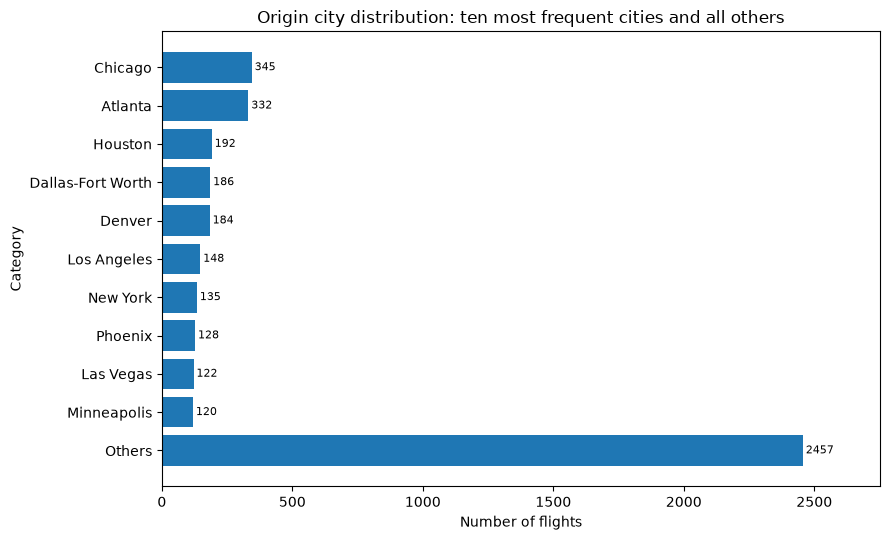

Saved figures/A2_O_CITY_bar.png


In [38]:
save_bar_chart(o_city_report, "O_CITY",
               "Origin city distribution: ten most frequent cities and all others",
               horizontal=True)

Chicago is the most frequently recorded origin city with 345 flights, which is 7.93 per cent of the 4,349 records. Departures are spread widely across 213 cities, since the ten most common cities together account for only 43.50 per cent of flights and 39 cities appear just once.

#### O_STATE

The same frequency summary is applied to the origin state, which groups the origin cities into a smaller number of categories.

In [39]:
o_state_full = frequency_table("O_STATE")
o_state_report = report_table(o_state_full)

o_state_full.to_csv("outputs/A2_O_STATE_frequency_full.csv", index=False)
o_state_report.to_csv("outputs/A2_O_STATE_report_table.csv", index=False)

describe_categorical("O_STATE", o_state_full)
print()
print("Categories in the full table:", len(o_state_full))
print("Rows in the report table:", len(o_state_report))

o_state_report

Attribute: O_STATE
  Total observations n  : 4349
  Non-missing count     : 4349
  Missing count         : 0
  Unique categories     : 52
  Mode                  : TX
  Mode frequency        : 552
  Mode percentage       : 12.69%
  Share of top ten      : 65.49%
  Categories seen once  : 2

Categories in the full table: 52
Rows in the report table: 11


,Category,Frequency,Percentage
0,TX,552,12.69
1,CA,511,11.75
2,IL,358,8.23
3,GA,340,7.82
4,FL,292,6.71
5,CO,196,4.51
6,NY,179,4.12
7,AZ,150,3.45
8,NV,138,3.17
9,MI,132,3.04


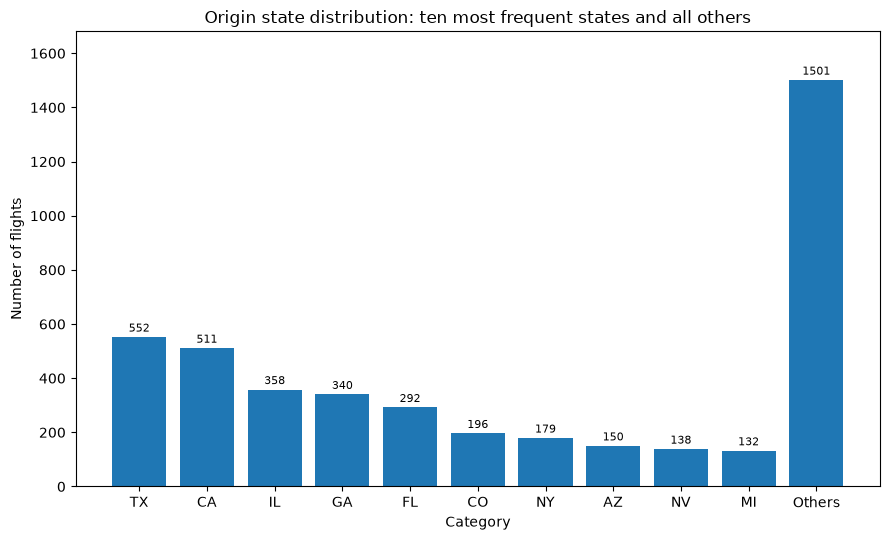

Saved figures/A2_O_STATE_bar.png


In [40]:
save_bar_chart(o_state_report, "O_STATE",
               "Origin state distribution: ten most frequent states and all others",
               horizontal=False)

Texas is the most frequently recorded origin state with 552 flights, or 12.69 per cent of records. Origin states are far more concentrated than origin cities, with the ten most common of the 52 states covering 65.49 per cent of flights.

#### D_CITY

The frequency summary is repeated for the destination city so that the arrival pattern can be compared with the departure pattern.

In [41]:
d_city_full = frequency_table("D_CITY")
d_city_report = report_table(d_city_full)

d_city_full.to_csv("outputs/A2_D_CITY_frequency_full.csv", index=False)
d_city_report.to_csv("outputs/A2_D_CITY_report_table.csv", index=False)

describe_categorical("D_CITY", d_city_full)
print()
print("Categories in the full table:", len(d_city_full))
print("Rows in the report table:", len(d_city_report))

d_city_report

Attribute: D_CITY
  Total observations n  : 4349
  Non-missing count     : 4349
  Missing count         : 0
  Unique categories     : 214
  Mode                  : Atlanta
  Mode frequency        : 353
  Mode percentage       : 8.12%
  Share of top ten      : 42.19%
  Categories seen once  : 42

Categories in the full table: 214
Rows in the report table: 11


,Category,Frequency,Percentage
0,Atlanta,353,8.12
1,Chicago,280,6.44
2,Houston,201,4.62
3,Dallas-Fort Worth,196,4.51
4,Los Angeles,175,4.02
5,Denver,161,3.70
6,San Francisco,121,2.78
7,Minneapolis,119,2.74
8,Phoenix,117,2.69
9,Las Vegas,112,2.58


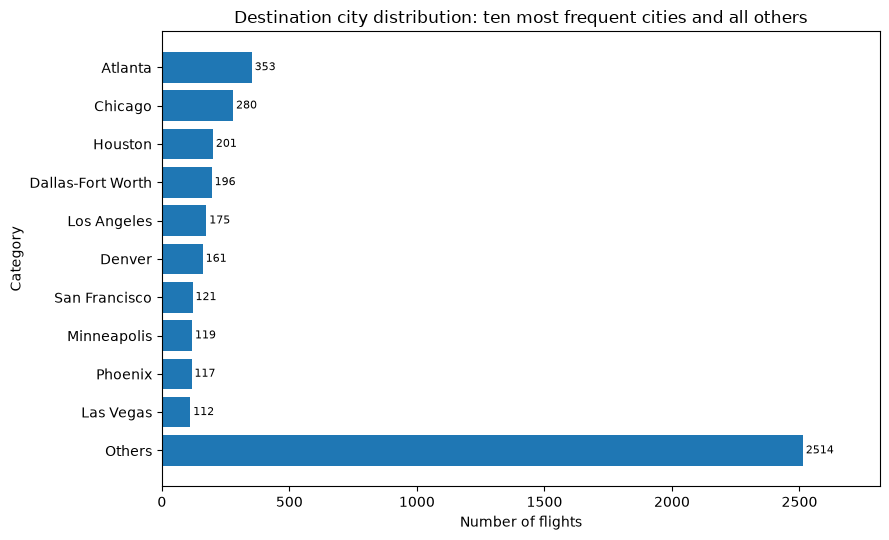

Saved figures/A2_D_CITY_bar.png


In [42]:
save_bar_chart(d_city_report, "D_CITY",
               "Destination city distribution: ten most frequent cities and all others",
               horizontal=True)

Atlanta is the most frequently recorded destination city with 353 flights, or 8.12 per cent of records. Arrivals are dispersed across 214 cities in much the same way as departures, with the ten most common cities covering 42.19 per cent and 42 cities appearing only once.

#### D_STATE

The frequency summary is repeated for the destination state, again showing the ten most common states with the rest combined.

In [43]:
d_state_full = frequency_table("D_STATE")
d_state_report = report_table(d_state_full)

d_state_full.to_csv("outputs/A2_D_STATE_frequency_full.csv", index=False)
d_state_report.to_csv("outputs/A2_D_STATE_report_table.csv", index=False)

describe_categorical("D_STATE", d_state_full)
print()
print("Categories in the full table:", len(d_state_full))
print("Rows in the report table:", len(d_state_report))

d_state_report

Attribute: D_STATE
  Total observations n  : 4349
  Non-missing count     : 4349
  Missing count         : 0
  Unique categories     : 51
  Mode                  : TX
  Mode frequency        : 577
  Mode percentage       : 13.27%
  Share of top ten      : 64.5%
  Categories seen once  : 1

Categories in the full table: 51
Rows in the report table: 11


,Category,Frequency,Percentage
0,TX,577,13.27
1,CA,565,12.99
2,GA,365,8.39
3,FL,305,7.01
4,IL,288,6.62
5,CO,179,4.12
6,NY,143,3.29
7,AZ,135,3.10
8,MI,124,2.85
9,NV,124,2.85


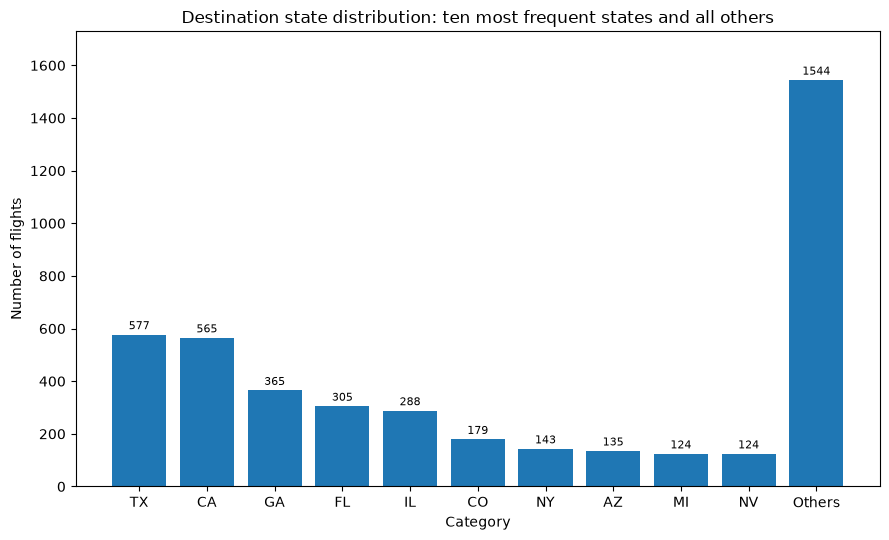

Saved figures/A2_D_STATE_bar.png


In [44]:
save_bar_chart(d_state_report, "D_STATE",
               "Destination state distribution: ten most frequent states and all others",
               horizontal=False)

Texas is also the most frequently recorded destination state, with 577 flights or 13.27 per cent of records. The 51 destination states show a similar concentration to the origin states, with the top ten accounting for 64.50 per cent, and Michigan and Nevada tie on 124 flights each.

#### AIRLINE_NAME

All six airlines are shown individually because the attribute has few enough categories to display in full, so no Others row is needed.

In [45]:
airline_name_full = frequency_table("AIRLINE_NAME")
airline_name_report = report_table(airline_name_full)

airline_name_full.to_csv("outputs/A2_AIRLINE_NAME_frequency_full.csv", index=False)
airline_name_report.to_csv("outputs/A2_AIRLINE_NAME_report_table.csv", index=False)

describe_categorical("AIRLINE_NAME", airline_name_full)
print()
print("Categories in the full table:", len(airline_name_full))
print("Rows in the report table:", len(airline_name_report))

airline_name_report

Attribute: AIRLINE_NAME
  Total observations n  : 4349
  Non-missing count     : 4349
  Missing count         : 0
  Unique categories     : 6
  Mode                  : Southwest Airlines Co.
  Mode frequency        : 1207
  Mode percentage       : 27.75%
  Share of top ten      : 100.0%
  Categories seen once  : 0

Categories in the full table: 6
Rows in the report table: 6


,Category,Frequency,Percentage
0,Southwest Airlines Co.,1207,27.75
1,Delta Air Lines Inc.,839,19.29
2,American Airlines Inc.,733,16.85
3,Skywest Airlines Inc.,569,13.08
4,Atlantic Southeast Airlines,521,11.98
5,United Air Lines Inc.,480,11.04


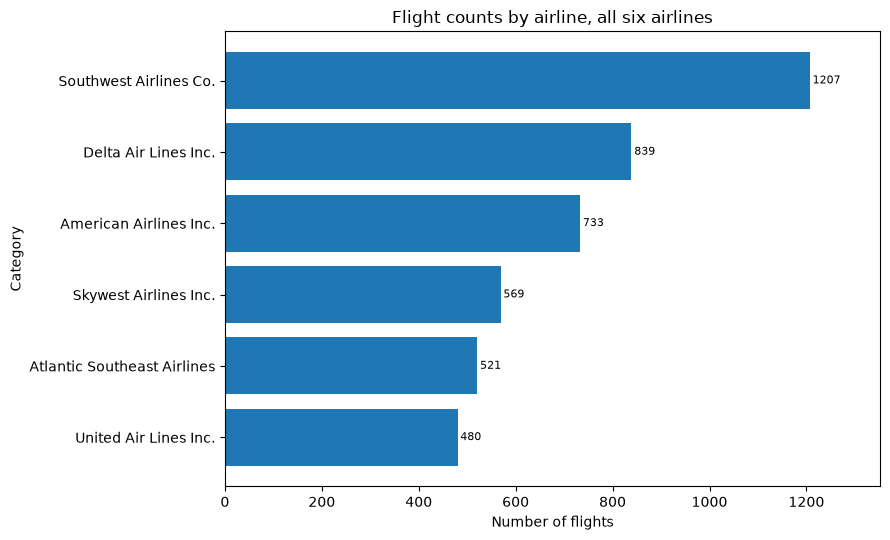

Saved figures/A2_AIRLINE_NAME_bar.png


In [46]:
save_bar_chart(airline_name_report, "AIRLINE_NAME",
               "Flight counts by airline, all six airlines",
               horizontal=True)

Southwest Airlines Co. is the most frequently recorded airline with 1,207 flights, or 27.75 per cent of records. The six airlines are spread far more evenly than the location attributes, ranging from 11.04 per cent for United Air Lines Inc. up to 27.75 per cent for Southwest Airlines Co.

### A2.2 Batch 1 summary table

The five individual summaries are collected into one compact table. This is the table that will be quoted in the report, with the full frequency tables kept in `outputs/` as supporting evidence.

In [47]:
summary_rows = []
full_tables = {
    "O_CITY": o_city_full,
    "O_STATE": o_state_full,
    "D_CITY": d_city_full,
    "D_STATE": d_state_full,
    "AIRLINE_NAME": airline_name_full,
}

for attribute in batch1_attributes:
    full_table = full_tables[attribute]
    column = df_raw[attribute]
    summary_rows.append({
        "Attribute": attribute,
        "N": len(df_raw),
        "Missing": int(column.isna().sum()),
        "Unique Categories": int(column.nunique(dropna=True)),
        "Mode": full_table.loc[0, "Category"],
        "Mode Frequency": int(full_table.loc[0, "Frequency"]),
        "Mode Percentage": full_table.loc[0, "Percentage"],
    })

batch1_summary = pd.DataFrame(summary_rows)
batch1_summary.to_csv("outputs/A2_batch1_categorical_summary.csv", index=False)
batch1_summary

,Attribute,N,Missing,Unique Categories,Mode,Mode Frequency,Mode Percentage
0,O_CITY,4349,0,213,Chicago,345,7.93
1,O_STATE,4349,0,52,TX,552,12.69
2,D_CITY,4349,0,214,Atlanta,353,8.12
3,D_STATE,4349,0,51,TX,577,13.27
4,AIRLINE_NAME,4349,0,6,Southwest Airlines Co.,1207,27.75


Every attribute in this batch has 4,349 observations with no missing values. The number of unique categories is the clearest difference between them, ranging from 6 airlines up to 214 destination cities, and the mode percentage shows how much of the data the largest single category holds in each case.

### A2.3 Validation of Batch 1

These checks confirm the tables and figures mechanically instead of by eye. One point needs explaining. Each percentage is rounded to two decimal places for display, so a table with many rows can drift slightly from an exact 100 per cent total. The tolerance below allows half a hundredth of a percentage point per row, which is the largest possible rounding error, so a table of 213 categories is permitted to drift by about one percentage point while the report tables must stay within a few hundredths. The frequency totals are checked exactly, since they involve no rounding.

In [48]:
def percentages_sum_to_100(table):
    """Allow for the rounding error introduced by displaying each percentage to two decimals."""
    tolerance = 0.005 * len(table) + 0.01
    return abs(table["Percentage"].sum() - 100) <= tolerance


def report_table_is_top10_plus_others(full_table, report):
    """Confirm a report table holds the top ten rows plus one correct Others row."""
    if len(report) != 11 or report.iloc[-1]["Category"] != "Others":
        return False
    top_matches = report.head(10).reset_index(drop=True).equals(full_table.head(10).reset_index(drop=True))
    expected_others = int(full_table["Frequency"].sum()) - int(full_table["Frequency"].head(10).sum())
    return top_matches and int(report.iloc[-1]["Frequency"]) == expected_others


expected_figures = [f"figures/A2_{a}_bar.png" for a in batch1_attributes]
expected_outputs = [f"outputs/A2_{a}_frequency_full.csv" for a in batch1_attributes]
expected_outputs += [f"outputs/A2_{a}_report_table.csv" for a in batch1_attributes]
expected_outputs += ["outputs/A2_batch1_categorical_summary.csv"]

report_tables = {"O_CITY": o_city_report, "O_STATE": o_state_report,
                 "D_CITY": d_city_report, "D_STATE": d_state_report,
                 "AIRLINE_NAME": airline_name_report}
print("Files expected:", len(expected_figures), "figures and", len(expected_outputs), "tables")

Files expected: 5 figures and 11 tables


In [49]:
a2_checks = {
    "1. All five attributes exist": all(a in df_raw.columns for a in batch1_attributes),
    "2. Missing count is zero for all five": all(df_raw[a].isna().sum() == 0 for a in batch1_attributes),
    "3. Frequency totals equal 4349 for every attribute": all(int(full_tables[a]["Frequency"].sum()) == 4349 for a in batch1_attributes),
    "4. Percentage totals are 100 within rounding": all(percentages_sum_to_100(full_tables[a]) for a in batch1_attributes)
                                                    and all(percentages_sum_to_100(report_tables[a]) for a in batch1_attributes),
    "5. Full table row counts equal the unique counts": all(len(full_tables[a]) == df_raw[a].nunique(dropna=True) for a in batch1_attributes),
    "6. O_CITY report table is top 10 plus correct Others": report_table_is_top10_plus_others(o_city_full, o_city_report),
    "7. O_STATE report table is top 10 plus correct Others": report_table_is_top10_plus_others(o_state_full, o_state_report),
    "8. D_CITY report table is top 10 plus correct Others": report_table_is_top10_plus_others(d_city_full, d_city_report),
    "9. D_STATE report table is top 10 plus correct Others": report_table_is_top10_plus_others(d_state_full, d_state_report),
    "10. AIRLINE_NAME report table holds all six airlines": len(airline_name_report) == 6 and df_raw["AIRLINE_NAME"].nunique() == 6,
    "11. AIRLINE_NAME has no Others row": "Others" not in list(airline_name_report["Category"]),
    "12. Summary mode equals the highest-frequency category": all(
        batch1_summary.loc[i, "Mode"] == full_tables[a]["Category"].iloc[0]
        and int(batch1_summary.loc[i, "Mode Frequency"]) == int(full_tables[a]["Frequency"].max())
        for i, a in enumerate(batch1_attributes)),
    "13. All five figure files exist": all(os.path.exists(p) for p in expected_figures),
    "14. All expected output CSV files exist": all(os.path.exists(p) for p in expected_outputs),
    "15. df_raw remains 4349 by 25": df_raw.shape == (4349, 25),
}

for description, passed in a2_checks.items():
    print("PASS" if passed else "FAIL", description)

print()
print("Checks passed:", sum(a2_checks.values()), "of", len(a2_checks))

PASS 1. All five attributes exist
PASS 2. Missing count is zero for all five
PASS 3. Frequency totals equal 4349 for every attribute
PASS 4. Percentage totals are 100 within rounding
PASS 5. Full table row counts equal the unique counts
PASS 6. O_CITY report table is top 10 plus correct Others
PASS 7. O_STATE report table is top 10 plus correct Others
PASS 8. D_CITY report table is top 10 plus correct Others
PASS 9. D_STATE report table is top 10 plus correct Others
PASS 10. AIRLINE_NAME report table holds all six airlines
PASS 11. AIRLINE_NAME has no Others row
PASS 12. Summary mode equals the highest-frequency category
PASS 13. All five figure files exist
PASS 14. All expected output CSV files exist
PASS 15. df_raw remains 4349 by 25

Checks passed: 15 of 15


All Batch 1 checks pass. The five nominal attributes are complete, their frequencies account for every one of the 4,349 records, the Others rows contain exactly the categories left out of each top ten, and the raw data is unchanged at 4,349 rows and 25 columns. The remaining A2 attributes are covered in later batches.